Data shape: (7043, 21)

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%

Data shape after cleaning: (7032, 20)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7032, 31)
Features: 30

Feature matrix: (7032, 30)
Target vector: (7032,)

Train set: (5625, 30)
Test set: (1407, 30)

Train churn rate: 26.58%
Test churn rate: 26.58%

After SMOTE:
Train set: (8260, 30)
Churn distribution:
Churn
0    4130
1    4130
Name: count, dtype: int64

TRAINING MODEL...
Training complete!

MODEL PERFORMANCE
Accuracy: 0.7683 (76.83%)
ROC-AUC: 0.8323

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.84      1033
       Churn       0.55      0.67      0.61    

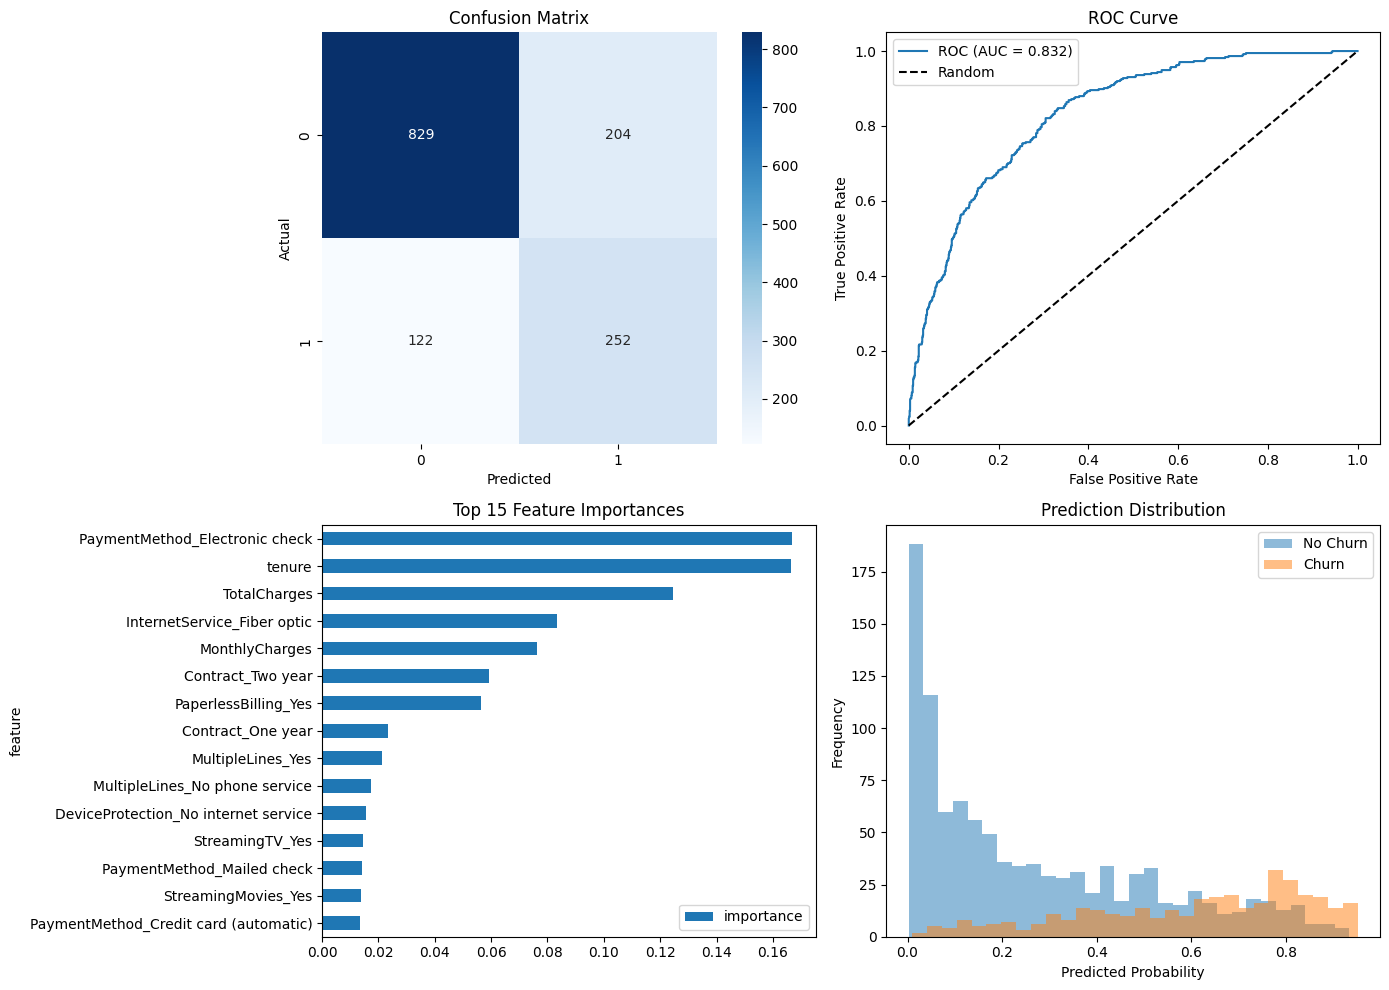


MODEL SAVED SUCCESSFULLY!
Model file: churn_model.pkl
Features file: feature_names.pkl
Total features: 30

Top 10 Important Features:
  PaymentMethod_Electronic check: 0.1668
  tenure: 0.1665
  TotalCharges: 0.1244
  InternetService_Fiber optic: 0.0834
  MonthlyCharges: 0.0761
  Contract_Two year: 0.0593
  PaperlessBilling_Yes: 0.0563
  Contract_One year: 0.0233
  MultipleLines_Yes: 0.0214
  MultipleLines_No phone service: 0.0175


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             roc_curve)
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Data shape:", df.shape)
print("\nTarget distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.2%}")

df = df.drop('customerID', axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nData shape after cleaning: {df.shape}")

categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(categorical_cols)}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Features: {df_encoded.shape[1] - 1}")

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"\nFeature matrix: {X.shape}")
print(f"Target vector: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train set: {X_train_sm.shape}")
print(f"Churn distribution:")
print(pd.Series(y_train_sm).value_counts())

print("\n" + "="*60)
print("TRAINING MODEL...")
print("="*60)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_sm, y_train_sm)

print("Training complete!")

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()

feature_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

feature_imp.plot(x='feature', y='importance', kind='barh', ax=axes[1, 0])
axes[1, 0].set_title('Top 15 Feature Importances')
axes[1, 0].invert_yaxis()

axes[1, 1].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.5, label='No Churn')
axes[1, 1].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.5, label='Churn')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

feature_names = list(X.columns)
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("\n" + "="*60)
print("MODEL SAVED SUCCESSFULLY!")
print("="*60)
print(f"Model file: churn_model.pkl")
print(f"Features file: feature_names.pkl")
print(f"Total features: {len(feature_names)}")

print("\nTop 10 Important Features:")
top_features = feature_imp.head(10)
for idx, row in top_features.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")